In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
data = pd.read_excel(r"C:\Users\Windows\OneDrive\Documents\GitHub\New folder\Sales-Data-Analysis.xlsx")

In [3]:
data.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,NaN,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City
1,NaN,10452,2022-11-07 00:00:00,Fries,3.49,573.065903,Online,Gift Card,Tom Jackson,London
2,NaN,10453,2022-11-07 00:00:00,Beverages,2.95,745.762712,Online,Gift Card,Pablo Perez,Madrid
3,NaN,10454,2022-11-07 00:00:00,Sides & Other,4.99,200.400802,In-store,Gift Card,Joao Silva,Lisbon
4,NaN,10455,2022-11-08 00:00:00,Burgers,12.99,569.668976,In-store,Credit Card,Walter Muller,Berlin


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257 entries, 0 to 256
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  0 non-null      float64
 1   Unnamed: 1  257 non-null    object 
 2   Unnamed: 2  257 non-null    object 
 3   Unnamed: 3  257 non-null    object 
 4   Unnamed: 4  257 non-null    object 
 5   Unnamed: 5  257 non-null    object 
 6   Unnamed: 6  257 non-null    object 
 7   Unnamed: 7  257 non-null    object 
 8   Unnamed: 8  257 non-null    object 
 9   Unnamed: 9  257 non-null    object 
dtypes: float64(1), object(9)
memory usage: 20.2+ KB


# Data Processing

In [5]:
data = data.drop(columns = "Unnamed: 0")

In [6]:
data.loc[0]
data.columns = data.loc[0]

In [7]:
data = data.drop(0)

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 256 entries, 1 to 256
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Order ID        256 non-null    object
 1   Date            256 non-null    object
 2   Product         256 non-null    object
 3   Price           256 non-null    object
 4   Quantity        256 non-null    object
 5   Purchase Type   256 non-null    object
 6   Payment Method  256 non-null    object
 7   Manager         256 non-null    object
 8   City            256 non-null    object
dtypes: object(9)
memory usage: 18.1+ KB


## Consider the Manager Column

In [9]:
data.head()

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City
1,10452,2022-11-07 00:00:00,Fries,3.49,573.065903,Online,Gift Card,Tom Jackson,London
2,10453,2022-11-07 00:00:00,Beverages,2.95,745.762712,Online,Gift Card,Pablo Perez,Madrid
3,10454,2022-11-07 00:00:00,Sides & Other,4.99,200.400802,In-store,Gift Card,Joao Silva,Lisbon
4,10455,2022-11-08 00:00:00,Burgers,12.99,569.668976,In-store,Credit Card,Walter Muller,Berlin
5,10456,2022-11-08 00:00:00,Chicken Sandwiches,9.95,201.005025,In-store,Credit Card,Walter Muller,Berlin


In [10]:
data["Manager"]

1        Tom      Jackson
2             Pablo Perez
3           Joao    Silva
4           Walter Muller
5           Walter Muller
              ...        
252         Walter Muller
253         Walter Muller
254         Walter Muller
255         Walter Muller
256         Joao    Silva
Name: Manager, Length: 256, dtype: object

In [11]:
data["Manager"].unique()

array(['Tom      Jackson', '       Pablo Perez', 'Joao    Silva',
       'Walter Muller', 'Remy    Monet', 'Remy Monet',
       '       Remy Monet', 'Remy     Monet', 'Pablo Perez',
       'Pablo   Perez', 'Pablo  Perez', 'Pablo    Perez', 'Joao Silva',
       'Tom Jackson'], dtype=object)

In [12]:
data["Manager"] = data["Manager"].str.strip().str.replace(r"\s+", ' ', regex = True)

In [13]:
data["Manager"].unique()

array(['Tom Jackson', 'Pablo Perez', 'Joao Silva', 'Walter Muller',
       'Remy Monet'], dtype=object)

## Removing the duplicate records

In [14]:
data.describe()

C:\Users\Windows\AppData\Local\Temp\ipykernel_12524\3175101911.py:1: FutureWarning: The behavior of value_counts with object-dtype is deprecated. In a future version, this will *not* perform dtype inference on the resulting index. To retain the old behavior, use `result.index = result.index.infer_objects()`
  data.describe()


,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City
count,256,256,256,256.00,256.000000,256,256,256,256
unique,254,53,5,7.00,29.000000,3,3,5,5
top,10454,2022-12-18 00:00:00,Chicken Sandwiches,12.99,200.400802,Online,Credit Card,Joao Silva,Lisbon
freq,2,6,53,52.00,50.000000,108,120,77,77


In [15]:
data[data.duplicated()]

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City
206,10656,2022-12-18 00:00:00,Chicken Sandwiches,9.95,221.105528,Online,Gift Card,Joao Silva,Lisbon
256,10454,2022-11-07 00:00:00,Sides & Other,4.99,200.400802,In-store,Gift Card,Joao Silva,Lisbon


In [16]:
data = data.drop_duplicates()

In [17]:
data

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City
1,10452,2022-11-07 00:00:00,Fries,3.49,573.065903,Online,Gift Card,Tom Jackson,London
2,10453,2022-11-07 00:00:00,Beverages,2.95,745.762712,Online,Gift Card,Pablo Perez,Madrid
3,10454,2022-11-07 00:00:00,Sides & Other,4.99,200.400802,In-store,Gift Card,Joao Silva,Lisbon
4,10455,2022-11-08 00:00:00,Burgers,12.99,569.668976,In-store,Credit Card,Walter Muller,Berlin
5,10456,2022-11-08 00:00:00,Chicken Sandwiches,9.95,201.005025,In-store,Credit Card,Walter Muller,Berlin
...,...,...,...,...,...,...,...,...,...
251,10709,2022-12-28 00:00:00,Sides & Other,4.99,200.400802,Drive-thru,Gift Card,Walter Muller,Berlin
252,10710,2022-12-29 00:00:00,Burgers,12.99,754.426482,Drive-thru,Gift Card,Walter Muller,Berlin
253,10711,2022-12-29 00:00:00,Chicken Sandwiches,9.95,281.407035,Drive-thru,Gift Card,Walter Muller,Berlin
254,10712,2022-12-29 00:00:00,Fries,3.49,630.372493,Drive-thru,Gift Card,Walter Muller,Berlin


In [18]:
data.describe()

C:\Users\Windows\AppData\Local\Temp\ipykernel_12524\3175101911.py:1: FutureWarning: The behavior of value_counts with object-dtype is deprecated. In a future version, this will *not* perform dtype inference on the resulting index. To retain the old behavior, use `result.index = result.index.infer_objects()`
  data.describe()


,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City
count,254,254,254,254.00,254.000000,254,254,254,254
unique,254,53,5,7.00,29.000000,3,3,5,5
top,10452,2022-12-03 00:00:00,Burgers,12.99,200.400802,Online,Credit Card,Tom Jackson,London
freq,1,5,52,52.00,49.000000,107,120,75,75


## Replace price

In [19]:
data[data[["Product","Price"]].duplicated()== False]

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City
1,10452,2022-11-07 00:00:00,Fries,3.49,573.065903,Online,Gift Card,Tom Jackson,London
2,10453,2022-11-07 00:00:00,Beverages,2.95,745.762712,Online,Gift Card,Pablo Perez,Madrid
3,10454,2022-11-07 00:00:00,Sides & Other,4.99,200.400802,In-store,Gift Card,Joao Silva,Lisbon
4,10455,2022-11-08 00:00:00,Burgers,12.99,569.668976,In-store,Credit Card,Walter Muller,Berlin
5,10456,2022-11-08 00:00:00,Chicken Sandwiches,9.95,201.005025,In-store,Credit Card,Walter Muller,Berlin
29,10482,2022-11-13 00:00:00,Fries,25.5,630.372493,In-store,Credit Card,Joao Silva,Lisbon
30,10486,2022-11-14 00:00:00,Chicken Sandwiches,29.05,201.005025,In-store,Credit Card,Joao Silva,Lisbon


In [20]:
data["Price"] = data["Price"].replace({25.5:3.49, 29.05:9.95})

C:\Users\Windows\AppData\Local\Temp\ipykernel_12524\2713728110.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data["Price"] = data["Price"].replace({25.5:3.49, 29.05:9.95})


In [21]:
data["Price"].unique()

array([ 3.49,  2.95,  4.99, 12.99,  9.95])

## Converting the datatype of columns

In [22]:
data.dtypes

0
Order ID           object
Date               object
Product            object
Price             float64
Quantity           object
Purchase Type      object
Payment Method     object
Manager            object
City               object
dtype: object

In [23]:
data["Quantity"] = data["Quantity"].astype(int)

In [24]:
data["Price"] = data["Price"].astype(float)

In [25]:
data["Order ID"] = data["Order ID"].astype(int)

In [26]:
data["Date"] = pd.to_datetime(data.Date)

In [27]:
data.dtypes

0
Order ID                   int64
Date              datetime64[ns]
Product                   object
Price                    float64
Quantity                   int64
Purchase Type             object
Payment Method            object
Manager                   object
City                      object
dtype: object

# Analyzing Data

## 1. Most preffered payment method ? 

In [28]:
data["Payment Method"].value_counts()

Payment Method
Credit Card    120
Cash            76
Gift Card       58
Name: count, dtype: int64

In [29]:
data["Payment Method"].value_counts(normalize = True)*100

Payment Method
Credit Card    47.244094
Cash           29.921260
Gift Card      22.834646
Name: proportion, dtype: float64

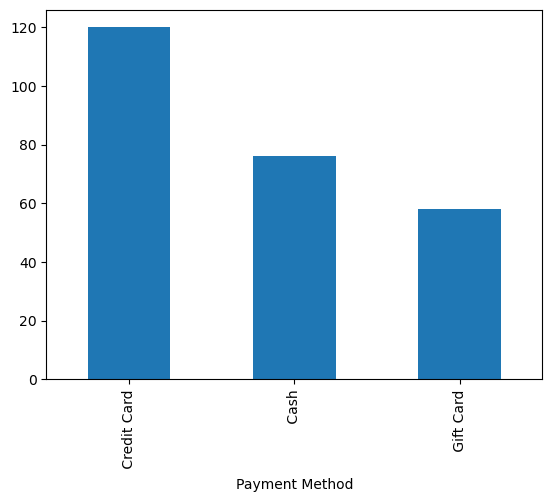

In [30]:
data["Payment Method"].value_counts().plot(kind = 'bar') ;

## 2. Most selling Product ? 

### By Quantity

In [31]:
data.head()

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City
1,10452,2022-11-07,Fries,3.49,573,Online,Gift Card,Tom Jackson,London
2,10453,2022-11-07,Beverages,2.95,745,Online,Gift Card,Pablo Perez,Madrid
3,10454,2022-11-07,Sides & Other,4.99,200,In-store,Gift Card,Joao Silva,Lisbon
4,10455,2022-11-08,Burgers,12.99,569,In-store,Credit Card,Walter Muller,Berlin
5,10456,2022-11-08,Chicken Sandwiches,9.95,201,In-store,Credit Card,Walter Muller,Berlin


In [32]:
data.groupby('Product')['Quantity'].sum().sort_values(ascending = False)

Product
Beverages             34938
Fries                 32016
Burgers               28996
Chicken Sandwiches    11132
Sides & Other          9800
Name: Quantity, dtype: int64

In [33]:
most_quantity = data.groupby('Product')['Quantity'].sum().sort_values(ascending = False)
most_quantity

Product
Beverages             34938
Fries                 32016
Burgers               28996
Chicken Sandwiches    11132
Sides & Other          9800
Name: Quantity, dtype: int64

In [34]:
most_quantity = most_quantity.reset_index()
most_quantity

,Product,Quantity
0,Beverages,34938
1,Fries,32016
2,Burgers,28996
3,Chicken Sandwiches,11132
4,Sides & Other,9800


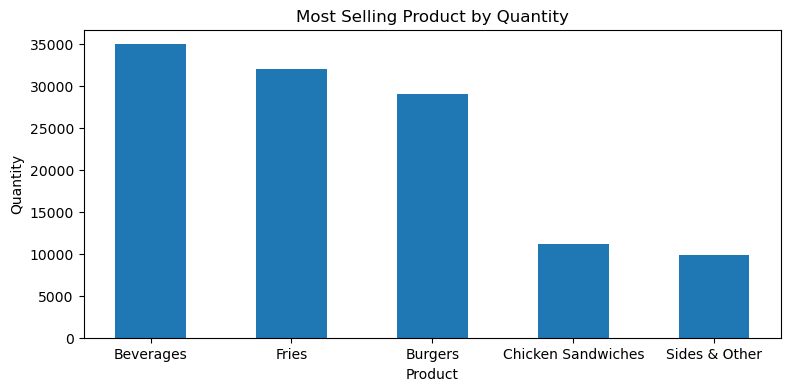

In [35]:
plt.figure(figsize = (9,4))
plt.bar(most_quantity["Product"],most_quantity["Quantity"], width = 0.5)
plt.xlabel("Product")
plt.ylabel("Quantity")
plt.title("Most Selling Product by Quantity")
plt.show;

### By Revenue

In [36]:
data.head()

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City
1,10452,2022-11-07,Fries,3.49,573,Online,Gift Card,Tom Jackson,London
2,10453,2022-11-07,Beverages,2.95,745,Online,Gift Card,Pablo Perez,Madrid
3,10454,2022-11-07,Sides & Other,4.99,200,In-store,Gift Card,Joao Silva,Lisbon
4,10455,2022-11-08,Burgers,12.99,569,In-store,Credit Card,Walter Muller,Berlin
5,10456,2022-11-08,Chicken Sandwiches,9.95,201,In-store,Credit Card,Walter Muller,Berlin


In [37]:
data["Revenue"] = data["Price"]*data["Quantity"]

In [38]:
data.groupby("Product")["Revenue"].sum().sort_values(ascending = False)

Product
Burgers               376658.04
Fries                 111735.84
Chicken Sandwiches    110763.40
Beverages             103067.10
Sides & Other          48902.00
Name: Revenue, dtype: float64

In [39]:
most_revenue = data.groupby("Product")["Revenue"].sum().sort_values(ascending = False).reset_index()
most_revenue

,Product,Revenue
0,Burgers,376658.04
1,Fries,111735.84
2,Chicken Sandwiches,110763.40
3,Beverages,103067.10
4,Sides & Other,48902.00


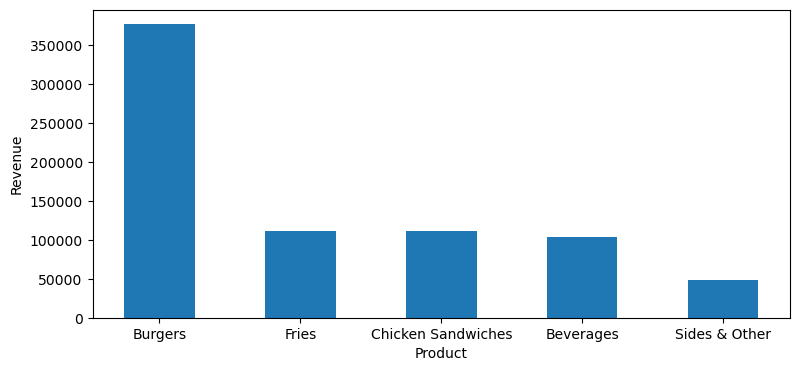

In [49]:
plt.figure(figsize = (9,4))
plt.bar(most_revenue["Product"],most_revenue["Revenue"], width = 0.5)
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.show;

### 3. Which city had maximum revenue ? 

In [41]:
data.head()

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City,Revenue
1,10452,2022-11-07,Fries,3.49,573,Online,Gift Card,Tom Jackson,London,1999.77
2,10453,2022-11-07,Beverages,2.95,745,Online,Gift Card,Pablo Perez,Madrid,2197.75
3,10454,2022-11-07,Sides & Other,4.99,200,In-store,Gift Card,Joao Silva,Lisbon,998.00
4,10455,2022-11-08,Burgers,12.99,569,In-store,Credit Card,Walter Muller,Berlin,7391.31
5,10456,2022-11-08,Chicken Sandwiches,9.95,201,In-store,Credit Card,Walter Muller,Berlin,1999.95


In [42]:
data["City"].nunique()

5

In [43]:
data.groupby("City")["Revenue"].sum().sort_values(ascending = False).reset_index()

,City,Revenue
0,Lisbon,223803.98
1,London,211001.83
2,Madrid,136098.22
3,Berlin,100492.73
4,Paris,79729.62


### 4. Which Manager earned maximum revenue ? 

In [44]:
data["Manager"].nunique()

5

In [46]:
data.groupby("Manager")["Revenue"].sum().sort_values(ascending = False).reset_index()

,Manager,Revenue
0,Joao Silva,223803.98
1,Tom Jackson,211001.83
2,Pablo Perez,136098.22
3,Walter Muller,100492.73
4,Remy Monet,79729.62


### 5. Date wise Revenue

In [50]:
data.head()

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City,Revenue
1,10452,2022-11-07,Fries,3.49,573,Online,Gift Card,Tom Jackson,London,1999.77
2,10453,2022-11-07,Beverages,2.95,745,Online,Gift Card,Pablo Perez,Madrid,2197.75
3,10454,2022-11-07,Sides & Other,4.99,200,In-store,Gift Card,Joao Silva,Lisbon,998.00
4,10455,2022-11-08,Burgers,12.99,569,In-store,Credit Card,Walter Muller,Berlin,7391.31
5,10456,2022-11-08,Chicken Sandwiches,9.95,201,In-store,Credit Card,Walter Muller,Berlin,1999.95


In [52]:
data["Date"].dtype

dtype('<M8[ns]')

In [79]:
DataByDate = data.groupby("Date")["Revenue"].sum().reset_index()
DataByDate.head()

,Date,Revenue
0,2022-11-07,5195.52
1,2022-11-08,12389.03
2,2022-11-09,14191.33
3,2022-11-10,13193.33
4,2022-11-11,14390.26


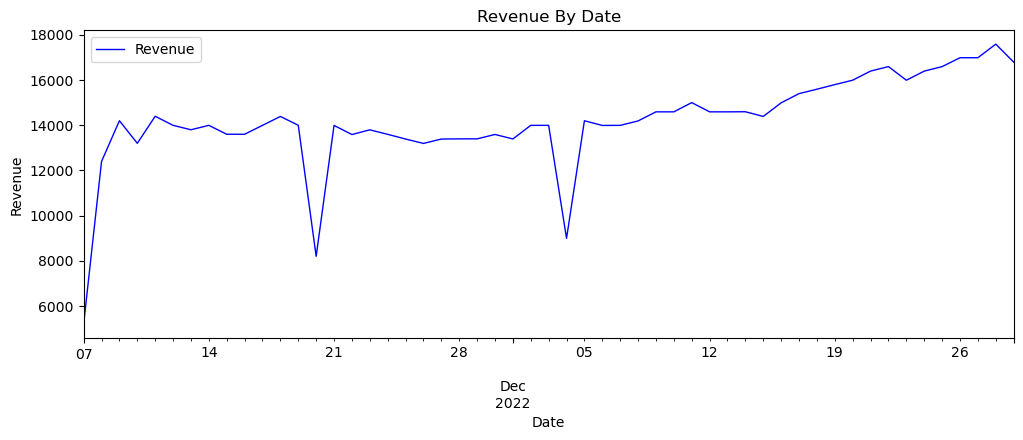

In [78]:
DataByDate.plot(
    x="Date",
    y="Revenue",
    color="blue",
    linewidth=1,
    figsize=(12,4)
)

plt.title("Revenue By Date")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()

### 6. Average Revenue

In [66]:
data["Revenue"].mean()
print(data["Revenue"].mean())

2957.190472440945


### 7. Average Revenue of November & December month

In [70]:
data["Month"] = data["Date"].dt.month
data

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City,Revenue,Month
1,10452,2022-11-07,Fries,3.49,573,Online,Gift Card,Tom Jackson,London,1999.77,11
2,10453,2022-11-07,Beverages,2.95,745,Online,Gift Card,Pablo Perez,Madrid,2197.75,11
3,10454,2022-11-07,Sides & Other,4.99,200,In-store,Gift Card,Joao Silva,Lisbon,998.00,11
4,10455,2022-11-08,Burgers,12.99,569,In-store,Credit Card,Walter Muller,Berlin,7391.31,11
5,10456,2022-11-08,Chicken Sandwiches,9.95,201,In-store,Credit Card,Walter Muller,Berlin,1999.95,11
...,...,...,...,...,...,...,...,...,...,...,...
251,10709,2022-12-28,Sides & Other,4.99,200,Drive-thru,Gift Card,Walter Muller,Berlin,998.00,12
252,10710,2022-12-29,Burgers,12.99,754,Drive-thru,Gift Card,Walter Muller,Berlin,9794.46,12
253,10711,2022-12-29,Chicken Sandwiches,9.95,281,Drive-thru,Gift Card,Walter Muller,Berlin,2795.95,12
254,10712,2022-12-29,Fries,3.49,630,Drive-thru,Gift Card,Walter Muller,Berlin,2198.70,12


In [71]:
data.groupby("Month")["Revenue"].mean().reset_index()

,Month,Revenue
0,11,2779.968496
1,12,3099.219433
